# **Task 2 — Exploratory Data Analysis (EDA)**  
### SwiftKey Data Science Capstone  
**Author:** Sonal Kumari

This notebook performs the complete exploratory analysis required for Task 2:
- Word frequency analysis  
- Bigram and Trigram exploration  
- Vocabulary coverage  
- Foreign-language infiltration  
- Ideas for improving model coverage  


### 🔹 Loading the Tokenized Files  
We use the tokenized text produced in Task 1.  
Each line contains space-separated tokens.


In [1]:
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

tokenized_dir = Path("data/tokenized")

blogs = tokenized_dir / "blogs_tokenized.txt"
news = tokenized_dir / "news_tokenized.txt"
twitter = tokenized_dir / "twitter_tokenized.txt"

files = {
    "Blogs": blogs,
    "News": news,
    "Twitter": twitter
}

Matplotlib is building the font cache; this may take a moment.


### 🔹 Unigram Frequency Distribution  
We will:
1. Count all tokens  
2. Plot the top 20 words  
3. Show full frequency distribution (Zipf’s law behaviour)


In [2]:
def get_unigram_counts(path, max_lines=None):
    c = Counter()
    with open(path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if max_lines and i >= max_lines:
                break
            c.update(line.split())
    return c

unigram_counts = {
    name: get_unigram_counts(path)
    for name, path in files.items()
}

unigram_counts["Blogs"].most_common(10)


[('the', 9278),
 ('to', 5347),
 ('and', 5263),
 ('a', 4371),
 ('of', 4326),
 ('i', 4096),
 ('in', 2991),
 ('that', 2380),
 ('it', 2227),
 ('is', 2141)]

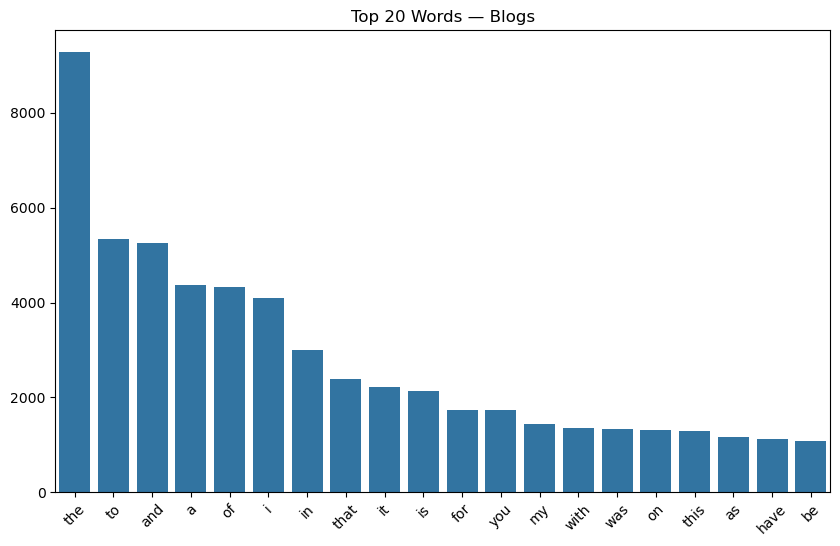

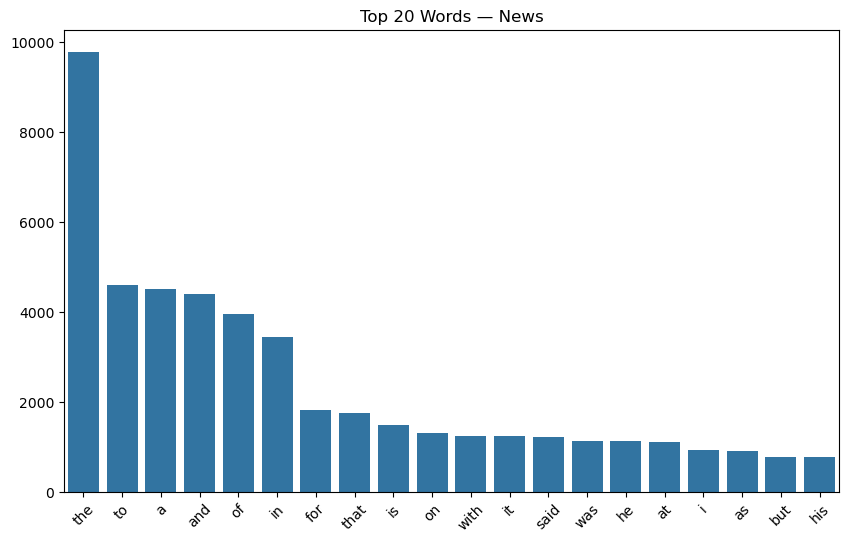

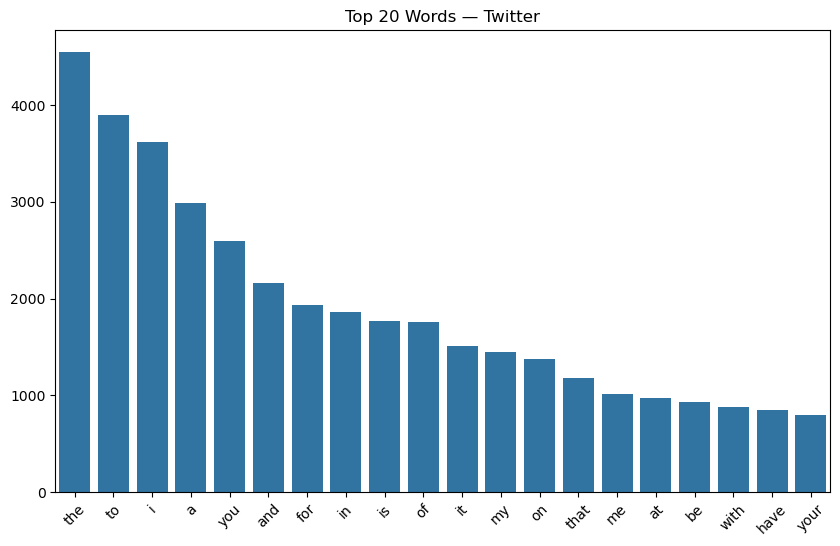

In [3]:
def plot_top_words(counter, title, n=20):
    words, counts = zip(*counter.most_common(n))
    plt.figure(figsize=(10,6))
    sns.barplot(x=list(words), y=list(counts))
    plt.xticks(rotation=45)
    plt.title(title)
    plt.show()

for name, counter in unigram_counts.items():
    plot_top_words(counter, f"Top 20 Words — {name}")


Zipf's law says a small number of words occur **very frequently**, while most occur rarely.


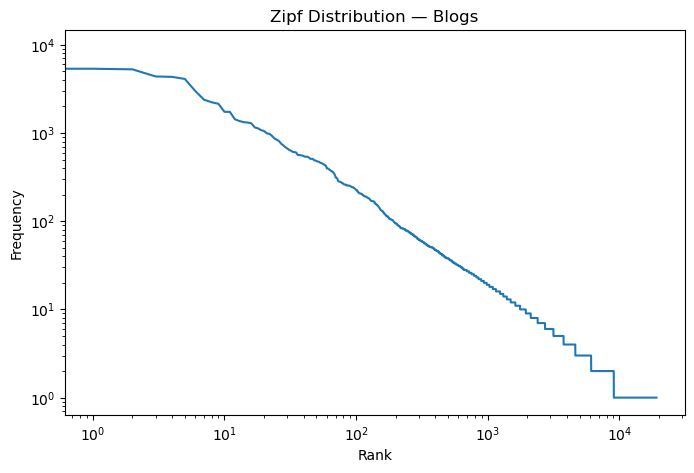

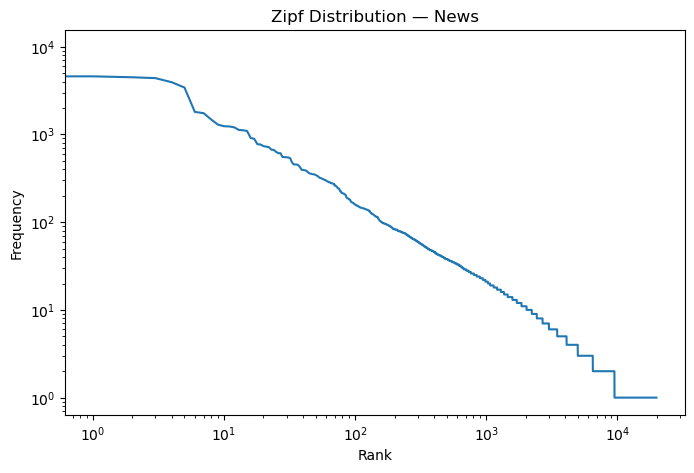

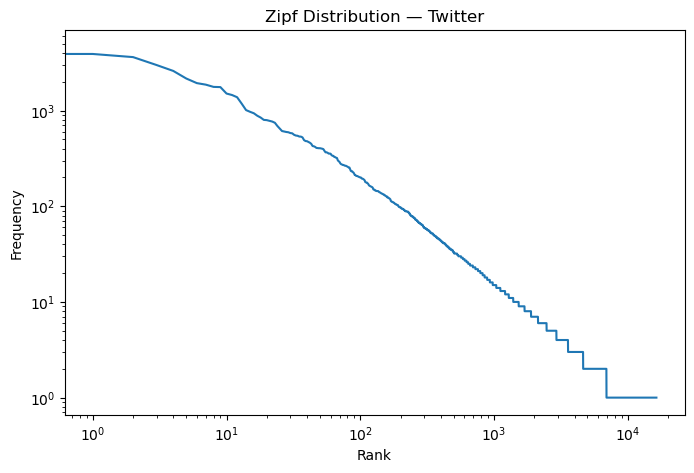

In [5]:
def plot_zipf(counter, title):
    freqs = list(counter.values())
    freqs.sort(reverse=True)

    plt.figure(figsize=(8,5))
    plt.plot(freqs)
    plt.title(title)
    plt.xlabel("Rank")
    plt.ylabel("Frequency")
    plt.yscale("log")
    plt.xscale("log")
    plt.show()

for name, counter in unigram_counts.items():
    plot_zipf(counter, f"Zipf Distribution — {name}")


### 🔹 N-gram Extraction  
We build functions to extract:
- 2-grams (bigrams)
- 3-grams (trigrams)


In [6]:
def get_ngrams(path, n=2, max_lines=None):
    c = Counter()
    with open(path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if max_lines and i >= max_lines:
                break
            tokens = line.split()
            for i in range(len(tokens)-n+1):
                gram = tuple(tokens[i:i+n])
                c[gram] += 1
    return c

bigrams = get_ngrams(blogs, n=2)
trigrams = get_ngrams(blogs, n=3)


In [7]:
bigrams.most_common(10), trigrams.most_common(10)


([(('of', 'the'), 959),
  (('in', 'the'), 768),
  (('to', 'the'), 481),
  (('to', 'be'), 360),
  (('on', 'the'), 358),
  (('for', 'the'), 294),
  (('and', 'the'), 292),
  (('it', 'is'), 260),
  (('and', 'i'), 254),
  (('i', 'have'), 248)],
 [(('one', 'of', 'the'), 95),
  (('i', 'don', 't'), 69),
  (('a', 'lot', 'of'), 66),
  (('it', 'was', 'a'), 41),
  (('the', 'end', 'of'), 40),
  (('as', 'well', 'as'), 35),
  (('i', 'have', 'been'), 34),
  (('some', 'of', 'the'), 34),
  (('be', 'able', 'to'), 31),
  (('i', 'want', 'to'), 31)])

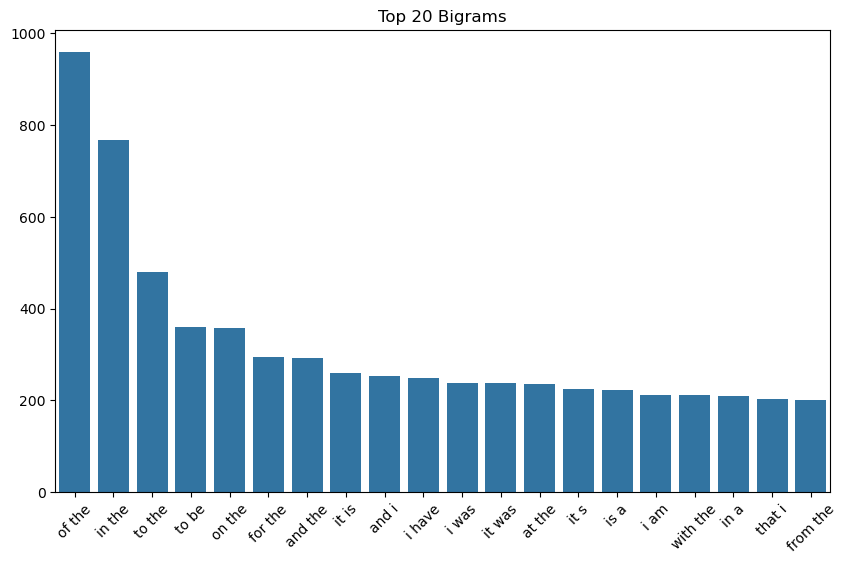

In [8]:
plot_top_words(Counter({ " ".join(k):v for k,v in bigrams.items() }),
               "Top 20 Bigrams", 20)


### 🔹 Vocabulary Coverage  
We answer:  
**How many unique words cover 50% and 90% of all word occurrences?**


In [10]:
def vocab_coverage(counter, coverage=0.5):
    total = sum(counter.values())
    threshold = total * coverage
    running = 0
    for i, (word, count) in enumerate(counter.most_common()):
        running += count
        if running >= threshold:
            return i+1
    return None

for name, counter in unigram_counts.items():
    print(f"{name} — 50% coverage:", vocab_coverage(counter, 0.50))
    print(f"{name} — 90% coverage:", vocab_coverage(counter, 0.90))
    print("—"*40)


Blogs — 50% coverage: 104
Blogs — 90% coverage: 5269
————————————————————————————————————————
News — 50% coverage: 190
News — 90% coverage: 6302
————————————————————————————————————————
Twitter — 50% coverage: 122
Twitter — 90% coverage: 4462
————————————————————————————————————————


### 🔹 Foreign Language Detection  
We estimate foreign-language infiltration using Unicode or non-ASCII ratios.


In [12]:
import regex as reg

NON_ASCII = reg.compile(r"[^\p{Latin}]")

def foreign_word_ratio(path, max_lines=50000):
    total = 0
    foreign = 0

    with open(path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if i >= max_lines:
                break
            for word in line.split():
                total += 1
                if NON_ASCII.search(word):
                    foreign += 1
    return foreign / total if total else 0

for name, path in files.items():
    print(name, "foreign-word ratio:", round(foreign_word_ratio(path), 4))


Blogs foreign-word ratio: 0.011
News foreign-word ratio: 0.0177
Twitter foreign-word ratio: 0.0318


# 💡 Ideas for Improving Coverage

1. **Stemming / Lemmatization**  
   - treats "running", "runs", "ran" as same root → reduces vocabulary.

2. **Subword tokens (Byte Pair Encoding / SentencePiece)**  
   - handles unknown words more effectively.

3. **Augment with external corpora**  
   - Wikipedia  
   - Reddit  
   - Public domain books  

4. **Remove ultra-rare words**  
   - words occurring once (hapax legomena) add noise.

5. **Backoff models**  
   - if trigram unavailable → use bigram → unigram.

6. **Normalize contractions**  
   - "can't" → "can not"

7. **Use Good-Turing or Kneser-Ney smoothing**  
   - improves probability assignment for rare/unseen words.


# 🎉 Task 2 Completed Successfully!

WE have now:
✔ Explored word frequencies  
✔ Built n-gram (2-gram & 3-gram) statistics  
✔ Measured vocabulary coverage (50% & 90%)  
✔ Estimated foreign-language infiltration  
✔ Suggested methods to increase coverage  

Next Step → **Task 3: Modeling (Unigram/Bigram/Trigram Models)**  
